In [9]:
from pyTNG import utils
from pyTNG import data_interface as _data_interface
import os
import pandas as pd
import numpy as np
import illustris_python as il
from pyTNG.spectra import StarSpectrumFactory
from pyTNG import spectra
import matplotlib.pyplot as plt
import time
import astropy.units as u
import scipy.integrate as integ
import pyTNG.utils as utils
from pyTNG.cosmology import TNGcosmo

In [12]:
h = TNGcosmo.h
snap_num = 13

In [2]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:80% !important; }</style>"))

In [14]:
basepath = "/virgo/simulations/IllustrisTNG/"
sim_name = 'L35n2160TNG'
sim = _data_interface.TNG50Simulation(os.path.join(basepath, sim_name))

In [126]:
dataset = next(sim.group_cat[snap_num].chunk_generator('subhalo'))

In [128]:
keys_needed = ['SubhaloGasMetallicity', 'SubhaloGasMetallicityHalfRad', 'SubhaloHalfmassRadType', 'SubhaloMassInHalfRad', 
               'SubhaloMassInHalfRadType', 'SubhaloMassInRad', 'SubhaloMassInRadType', 'SubhaloSFRinHalfRad', 
               'SubhaloSFRinRad', 'SubhaloPos']

In [129]:
sub_dict = {key: test[key] for key in keys_needed}

In [130]:
dataset_df = utils.dfFromArrDict(sub_dict)

In [140]:
columns_of_interest = [('SubhaloGasMetallicity', 0), 
                       ('SubhaloGasMetallicityHalfRad',0),
                       ('SubhaloHalfmassRadType', 4),
                       ('SubhaloMassInHalfRad', 0),
                       ('SubhaloMassInHalfRadType', 4),
                       ('SubhaloMassInRad', 0),
                       ('SubhaloMassInRadType', 0),
                       ('SubhaloMassInRadType', 4),
                       ('SubhaloSFRinHalfRad', 0),
                       ('SubhaloSFRinRad', 0),
                       ('SubhaloPos', 0),
                       ('SubhaloPos', 1),
                       ('SubhaloPos', 2)
                      ]

Remove all halos that do not have any star particles or star formation rate

In [ ]:
def reduce_df(df):
    filt = (df[('SubhaloMassInRadType', 4)]>0) & (df[('SubhaloSFRinRad', 0)]>0)
    new_df = df[filt]
    return new_df

In [141]:
df_to_save = test_df[columns_of_interest]
df_to_save = reduce_df(df_to_save)

In [4]:
path = f'/ptmp/mpa/ivkos/semianalytic_fesc/testing/sn0{snap_num}.pickle'

In [148]:
df_to_save.to_pickle(path)

In [5]:
df = pd.read_pickle(path)

In [16]:
z_start = sim.snap_cat[snap_num].header['Redshift']

In [58]:
sim_path = os.path.join(basepath, sim_name, 'output')

In [ ]:
stars = il.snapshot.loadSubhalo(sim_path,snap_num, 2368557,'stars')
utils.dropWindParticles(stars)
stars['Redshift'] = z_start
stars['ages'] = spectra._computeAgeFromFormationTime(stars['Redshift'],stars['GFM_StellarFormationTime'])

In [131]:
bpp = [
    '/ptmp/mpa/mglatzle/TNG_f_esc/BPASSv2.2.1_release-07-18-Tuatara/',
    '2.2.1',
    'chab300',
    'bin']
lam_min = 60 #approx 200ev
lam_max = 1
specFac = StarSpectrumFactory(bpp)#,  lam_max=1000, lam_min=10,)

In [179]:
stars['Redshift'] = z_start

In [180]:
stars['ages'] = spectra._computeAgeFromFormationTime(stars['Redshift'],stars['GFM_StellarFormationTime'])

In [57]:
stars['lambda']

KeyError: 'lambda'

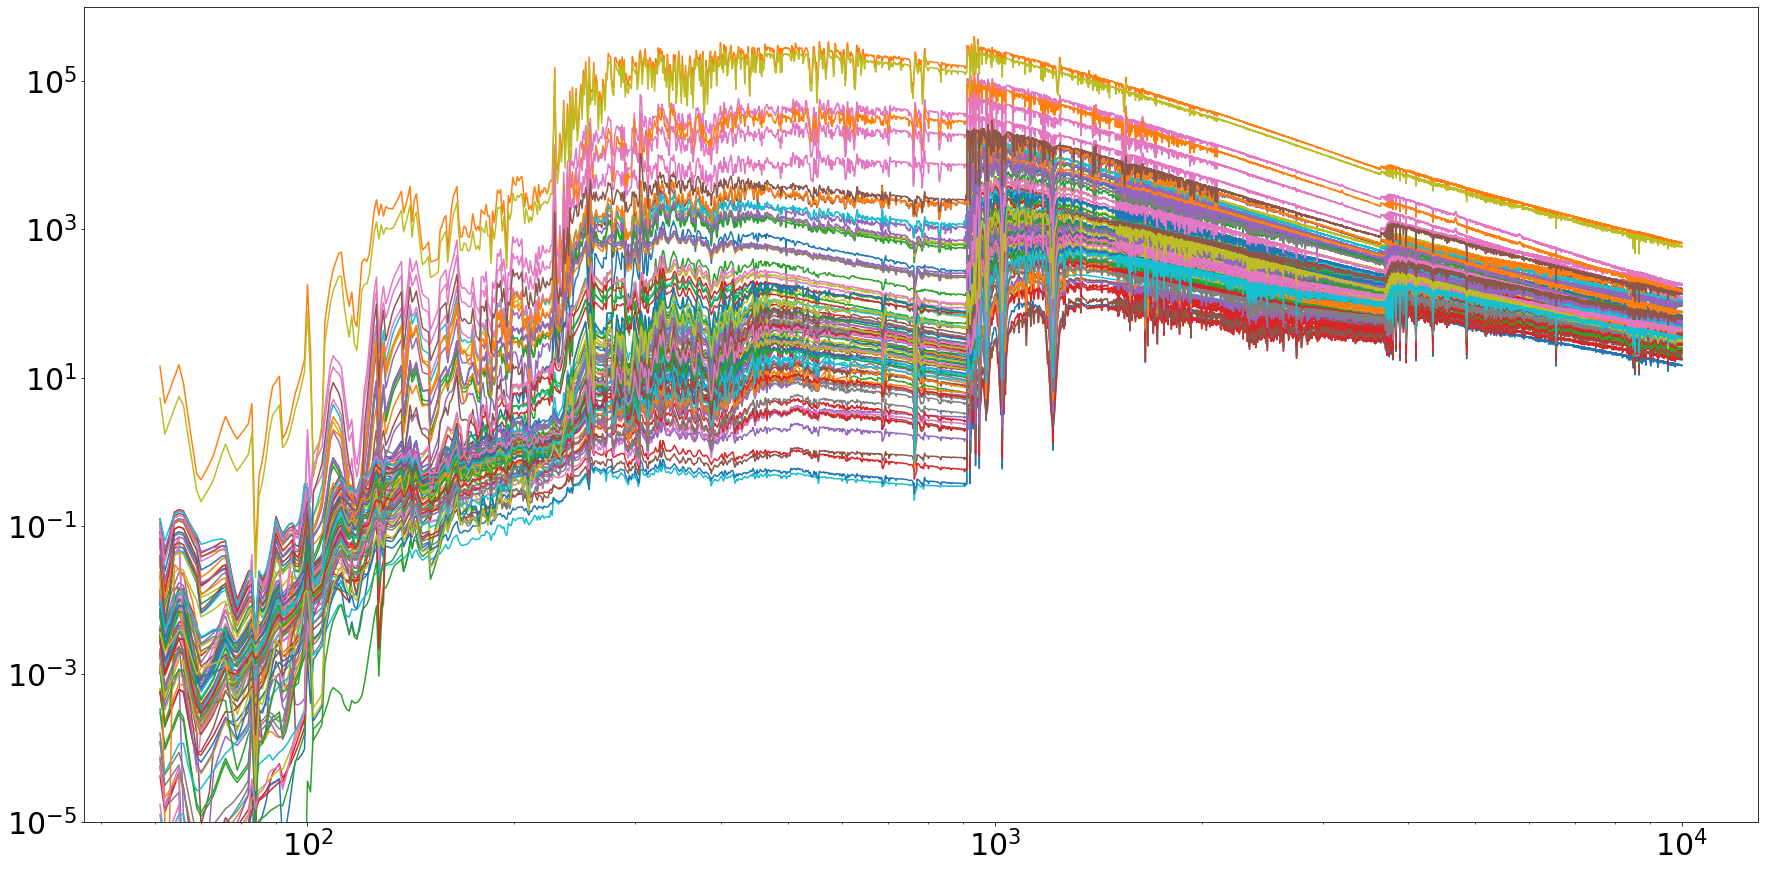

In [204]:
for i in range(100):
    plt.plot(stars['lambda'][60:10000], stars['spectra'][2000+i][60:10000])
plt.yscale('log')
plt.ylim(1e-5,1e6)
plt.rc('xtick', labelsize=30) 
plt.rc('ytick', labelsize=30)
plt.xscale('log')
plt.rcParams["figure.figsize"] = (30,15)

In [55]:
stars.keys()

dict_keys(['count', 'BirthPos', 'BirthVel', 'Coordinates', 'GFM_InitialMass', 'GFM_Metallicity', 'GFM_Metals', 'GFM_MetalsTagged', 'GFM_StellarFormationTime', 'GFM_StellarPhotometrics', 'Masses', 'ParticleIDs', 'Potential', 'StellarHsml', 'SubfindDMDensity', 'SubfindDensity', 'SubfindHsml', 'SubfindVelDisp', 'TimeStep', 'Velocities', 'Redshift', 'lambda', 'spectra', 'Q_0'])

In [183]:
rel_integrals = []
for i in range(stars['count']):
    integral = integ.simps(stars['spectra'][i], stars['lambda'])
    rel_integrals.append(integral/(stars['Masses'][i]*1e10/0.6774))

[autoreload of pyTNG.data_interface failed: Traceback (most recent call last):
  File "/u/ivkos/conda-envs/crash_analysis/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 245, in check
    superreload(m, reload, self.old_objects)
  File "/u/ivkos/conda-envs/crash_analysis/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 410, in superreload
    update_generic(old_obj, new_obj)
  File "/u/ivkos/conda-envs/crash_analysis/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 347, in update_generic
    update(a, b)
  File "/u/ivkos/conda-envs/crash_analysis/lib/python3.8/site-packages/IPython/extensions/autoreload.py", line 292, in update_class
    if (old_obj == new_obj) is True:
ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()
]


In [193]:
np.max(rel_integrals)

2175.3322383277596

In [194]:
np.min(rel_integrals)

5.3398587779033

In [190]:
np.average(rel_integrals)

118.511536595365

In [203]:
np.median(rel_integrals)

26.817010634268584

In [51]:
stars['Masses'][0]*1e10/0.6774

86566.6965725712

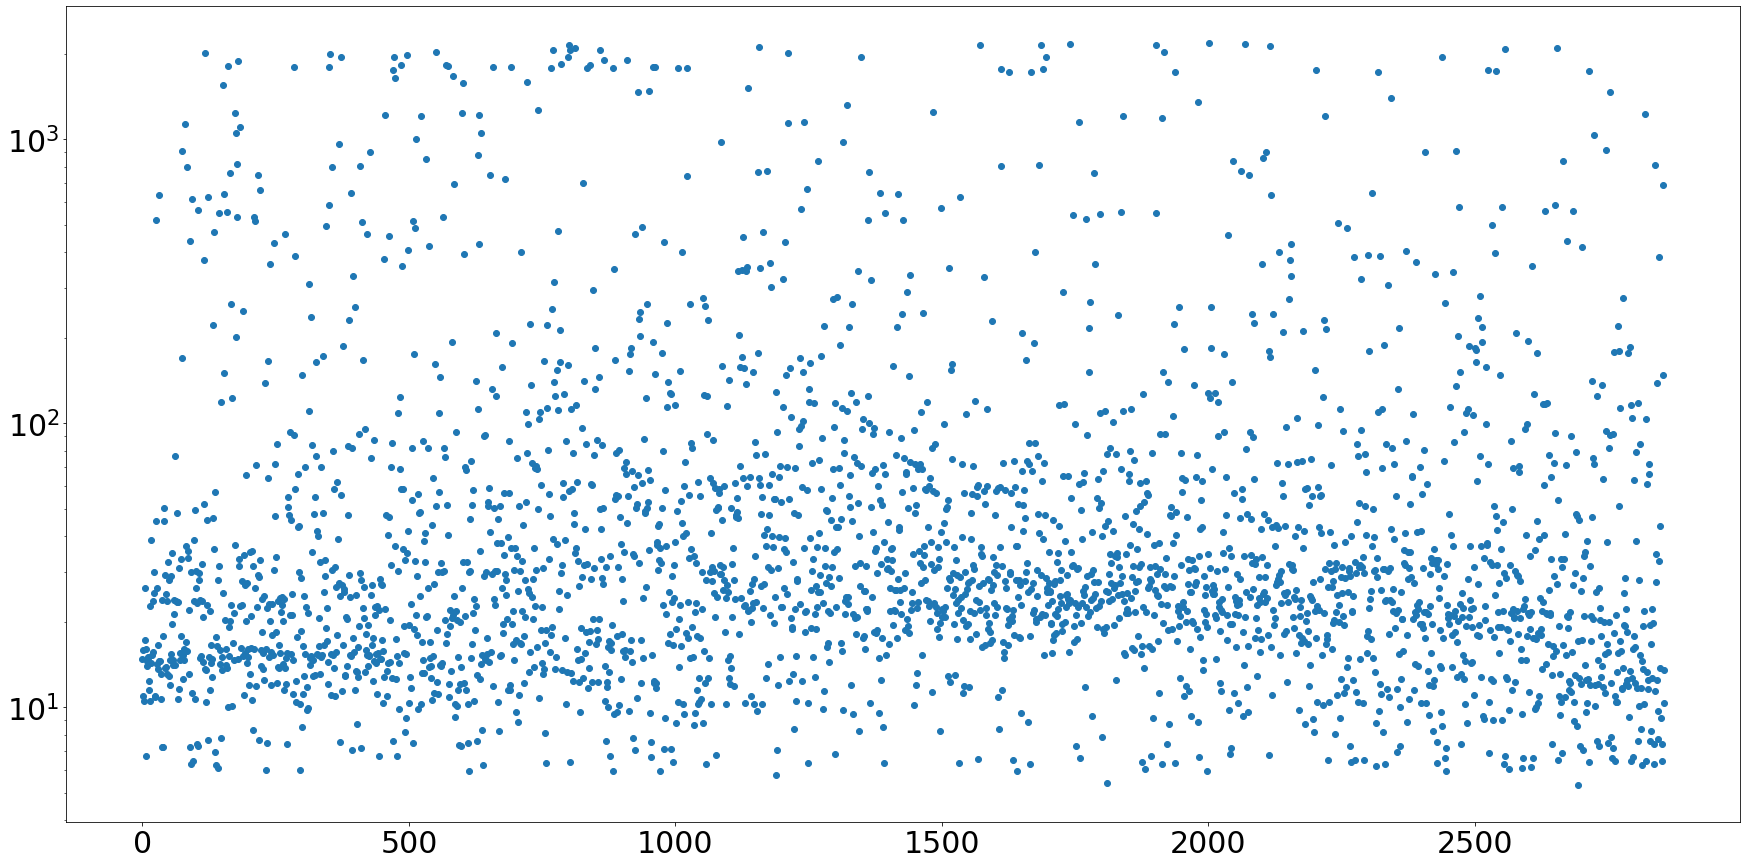

In [201]:
plt.scatter(np.arange(len(rel_integrals)), rel_integrals)
plt.rc('xtick', labelsize=30) 
plt.rc('ytick', labelsize=30)
plt.yscale('log')

In [213]:
df.columns

MultiIndex([(       'SubhaloGasMetallicity', 0),
            ('SubhaloGasMetallicityHalfRad', 0),
            (      'SubhaloHalfmassRadType', 4),
            (        'SubhaloMassInHalfRad', 0),
            (    'SubhaloMassInHalfRadType', 4),
            (            'SubhaloMassInRad', 0),
            (        'SubhaloMassInRadType', 0),
            (        'SubhaloMassInRadType', 4),
            (         'SubhaloSFRinHalfRad', 0),
            (             'SubhaloSFRinRad', 0),
            (                  'SubhaloPos', 0),
            (                  'SubhaloPos', 1),
            (                  'SubhaloPos', 2)],
           )

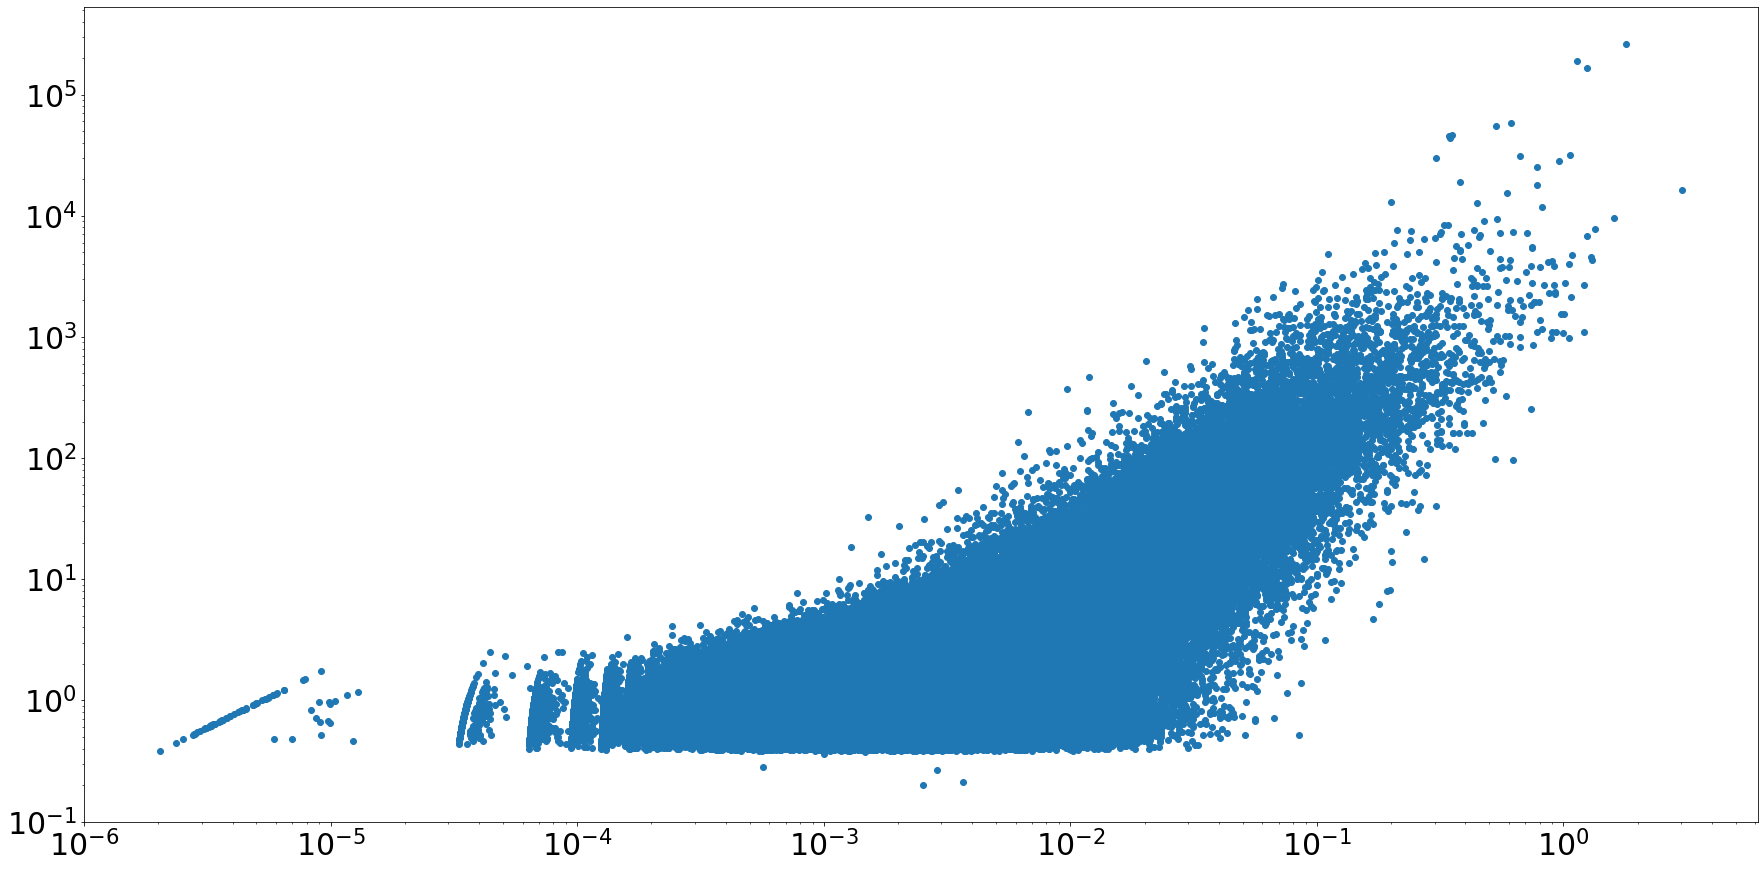

In [218]:
plt.scatter(df[('SubhaloMassInHalfRad', 0)], df[('SubhaloMassInHalfRadType', 4)]/np.average(stars['Masses']))
plt.rc('xtick', labelsize=30) 
plt.rc('ytick', labelsize=30)
plt.yscale('log')
plt.xscale('log')

In [69]:
stars['Q_0']

array([5.42784656e+46, 9.81174859e+46, 3.94215852e+48, 1.49560963e+47,
       5.41633219e+47, 2.52606824e+48, 2.63759503e+47, 3.43636721e+48,
       1.95905510e+46, 4.25444469e+47, 5.69788853e+48, 1.13155089e+48,
       1.48194609e+49, 3.04822764e+46, 1.15642953e+47, 7.71643853e+47,
       7.31613025e+46, 1.22250148e+47, 2.10815344e+46, 3.93382617e+47,
       3.97004335e+47, 3.93606011e+47, 6.11521595e+45, 6.58723206e+46,
       8.90628677e+46, 1.82421299e+48, 9.81420799e+46, 3.18980590e+48,
       9.80402619e+46, 5.21063530e+47, 6.75332453e+45, 3.72968689e+47,
       3.36885117e+48, 1.58648170e+48, 7.80937746e+46, 5.51976314e+45,
       2.11439434e+47, 2.72069195e+46, 9.34530453e+47, 1.35508776e+46,
       8.02576156e+47, 1.57723606e+47, 4.27648044e+46, 2.22037896e+48,
       5.64615931e+49, 2.79194674e+47, 3.59401257e+46, 1.50791851e+48,
       4.21523700e+48, 2.72422351e+47, 5.98458350e+47, 5.29137157e+47,
       5.94879874e+46, 1.73905070e+50, 1.28083389e+48, 1.70331513e+49,
      

In [ ]:
stars